In [1]:
#%% Imports
import pandas as pd

from popy.decoding.population_decoders import run_decoder

from popy.io_tools import load_behavior, load_neural_data
from popy.behavior_data_tools import *
from popy.neural_data_tools import *
from popy.decoding.population_decoders import linear_decoding
from popy.plotting.plotting_tools import plot_keypoints

from sklearn.preprocessing import LabelEncoder


In [2]:
def _preproc_data(neural_dataset_original, 
                  target_name, 
                  group_target_name=None
                  ):
    """
    Creates a matrix of regressors (X) and a vector of labels (y) from the neural data.
    
    Includes 3 steps:
    0. Creating data matrix and labels
    1. Remove nan trials
    2. If categorical, create numerical labels and balance the dataset
    
    Returns the data matrix and labels, ready to plug into the decoder.
    """

    neural_dataset = neural_dataset_original.copy(deep=True)

    # Step 0. Drop nan trials from labels (and groups)
    neural_dataset = remove_nan_labels(neural_dataset, target_name)  # drop trials with nan behavioural label
    if group_target_name is not None:
        neural_dataset = remove_nan_labels(neural_dataset, group_target_name)  
    
    # Step 1. Balance classes
    #X, y = _balance_categorical(X, y)
    n_classes = len(np.unique(neural_dataset[target_name].data))
    
    n_trials_before = len(neural_dataset)
    coords = None  # coords to balance the dataset on
    if n_classes <= 5 and group_target_name is None:  # if y is categorical and groups are not provided
        coords = target_name
    elif n_classes <= 5 and group_target_name is not None:  # if y is categorical and groups are provided
        coords = [target_name, group_target_name]
    elif n_classes > 5 and group_target_name is not None:  # if y is continuous and groups are provided
        coords = group_target_name

    if coords is not None:  
        neural_dataset = balance_labels(neural_dataset, coords=coords)  # TODO: uncomment this line after target CV decoder!!!!
        n_trials_after = len(neural_dataset)
        #print(f"Removed {n_trials_before - n_trials_after}/{n_trials_before} to balance the dataset on: {coords}")
    #else:
        #print(f"Dataset is not balanced, no trials removed.")

    # Step 2. Creating data matrix and labels
    X = neural_dataset.data
    y = neural_dataset[target_name].data
    if group_target_name is not None:
        y_groups = neural_dataset[group_target_name].data
    else:
        y_groups = None
    
    # Step 3. Encode categoricaxl labels
    if len(np.unique(y)) <= 5:  # if y is categorical
        y = _label_encoder(y)  # relabel from 0

    if y_groups is not None:  # if groups are provided, encode them as well
        y_groups = _label_encoder(y_groups)

    return X, y, y_groups


def _label_encoder(y):
    """
    Converts a vector of labels to numerical values.
    """
    # if there are nans
    assert not np.isnan(y).any(), "Label vector contains NaN values."

    # encode as integers
    le = LabelEncoder()
    le.fit(y)
    y_numerical = le.transform(y)

    return y_numerical

def load_data_for_decoder(monkey, session, n_extra_trials=(-1, 1)):
    # 1. Behavior data

    # Load behavior data
    behav = load_behavior(monkey, session)
    behav = drop_time_fields(behav)

    # add behav vars to decode
    behav = add_stay_value(behav)  # add shift value for its decoding
    # behav = add_switch_info(behav)  # add switch information for its decoding
    behav = add_history_of_feedback(behav, num_trials=8, one_column=False, add_history_of_targets=False)  # add history of feedback for its decoding

    '''for alpha in np.arange(0.05, 1, 0.05):
        behav = add_stay_value(behav, alpha=alpha)
        behav = behav.rename(columns={'stay_value': f'stay_value_{alpha:.2f}'})'''

    # set target == 2 to nan
    #behav['target'] = behav['target'].where(behav['target'] != 2, np.nan)  # set target == 2 to nan

    # shuffle non-nan ids: where its nan, keep as nan, but shuffle randomly the others
    '''targets = behav['target'].copy()
    behav['target_shuffled'] = _shuffle_preserve_nan(targets)'''

    # vreate 'stay_value_{target}' variable
    '''for target in np.unique(behav['target'].values):
        behav[f'stay_value_{target}'] = behav['stay_value'].copy()
        behav[f'stay_value_{target}'] = behav[f'stay_value_{target}'].where(behav['target'] == target, np.nan)  # keep only the values for the current target'''
    
    # 2. Neural data

    # Load neural data
    neural_data = load_neural_data(monkey, session, hz=1000)
    n_units_all = len(neural_data['unit'].values)

    # remove some units
    neural_data = remove_low_fr_neurons(neural_data, 1, print_usr_msg=False)
    neural_data = remove_trunctuated_neurons(neural_data, mode='remove', delay_limit=10, print_usr_msg=False)
    n_units_kept = len(neural_data['unit'].values)
    if len(neural_data['unit'].values) == 0:
        raise ValueError(f"No neurons left for {monkey}_{session}")
    
    # process neural data
    neural_data = add_firing_rates(neural_data, drop_spike_trains=True, method='gauss', std=.05)
    neural_data = downsample_time(neural_data, 100)
    neural_data = scale_neural_data(neural_data)
    neural_data = time_normalize_session(neural_data)

    # 3. build neural dataset and merge with behavior
    neural_dataset = build_trial_dataset(neural_data, mode='full_trial', n_extra_trials=n_extra_trials)
    neural_dataset = merge_behavior(neural_dataset, behav)

    print(f"Monkey: {monkey}, Session: {session} - Removed {n_units_all - n_units_kept} / {n_units_all} neurons")

    return neural_dataset

In [3]:
monkey, session, area = 'ka', '170720', 'MCC'
n_extra_trials = (0, 0)  # (n_extra_train_trials, n_extra_test_trials)

# load data
neural_dataset = load_data_for_decoder(monkey, session, n_extra_trials)

neural_dataset

Monkey: ka, Session: 170720 - Removed 25 / 46 neurons


<xarray.Dataset>
Dimensions:           (unit: 21, trial_id: 327, time: 750)
Coordinates: (12/25)
  * unit              (unit) object 'LPFC_04_01' 'LPFC_04_02' ... 'MCC_15_01'
    unit_id_original  (unit) int64 6 3 72 73 95 4 76 ... 164 45 53 49 56 62 176
    channel           (unit) int64 4 4 6 6 8 1 2 2 3 ... 11 12 12 13 13 14 15 15
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '170720' '170720' ... '170720' '170720'
    area              (unit) object 'LPFC' 'LPFC' 'LPFC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_3               (trial_id) float64 nan nan nan 0.0 0.0 ... 0.0 0.0 0.0 0.0
    R_4               (trial_id) float64 nan nan nan nan 0.0 ... 0.0 0.0 0.0 0.0
    R_5               (trial_id) float64 nan nan nan nan nan ... 1.0 0.0 0.0 0.0
    R_6               (trial_id) float64 nan nan nan nan nan ... 1.0 1.0 0.0 0.0
    R_7               (trial_id) float64 nan nan nan nan nan ... 0.0 1.0 1.0 0.0
    R_8               (trial_id) float64 nan nan nan nan nan ... 0.0 0.0 1.0 1.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 2.163 0.05197 ... -0.7636
Attributes:
    bin_size:  0.01

In [4]:
neural_data_temp = neural_dataset.where(neural_dataset.area == area, drop=True)

time = neural_data_temp.time.values
time_downsampled = np.unique(np.round(time, 1))  # downsample time to 2 decimal places
neural_data_temp = neural_data_temp.sel(time=time_downsampled, method="nearest")
neural_data_temp

<xarray.Dataset>
Dimensions:           (trial_id: 327, unit: 16, time: 76)
Coordinates: (12/25)
  * unit              (unit) object 'MCC_01_02' 'MCC_02_01' ... 'MCC_15_01'
    unit_id_original  (unit) int64 4 76 7 12 117 30 35 ... 45 53 49 56 62 176
    channel           (unit) int64 1 2 2 3 4 9 10 10 11 12 12 13 13 14 15 15
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '170720' '170720' ... '170720' '170720'
    area              (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_3               (trial_id) float64 nan nan nan 0.0 0.0 ... 0.0 0.0 0.0 0.0
    R_4               (trial_id) float64 nan nan nan nan 0.0 ... 0.0 0.0 0.0 0.0
    R_5               (trial_id) float64 nan nan nan nan nan ... 1.0 0.0 0.0 0.0
    R_6               (trial_id) float64 nan nan nan nan nan ... 1.0 1.0 0.0 0.0
    R_7               (trial_id) float64 nan nan nan nan nan ... 0.0 1.0 1.0 0.0
    R_8               (trial_id) float64 nan nan nan nan nan ... 0.0 0.0 1.0 1.0
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.5011 -0.7986 ... -0.7636
Attributes:
    bin_size:  0.01

In [5]:
X, y, groups = _preproc_data(neural_data_temp.firing_rates, 'stay_value')

X.shape, y.shape

((327, 16, 76), (327,))

In [11]:
from sklearn.model_selection import permutation_test_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, f_regression

kf = KFold(n_splits=10, shuffle=True, random_state=42)

alphas = np.logspace(-2, 4, 20)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('decoder', LinearRegression()), #RidgeCV(alphas=alphas, cv=kf))
])

scores = np.empty(X.shape[2])
perm_scores_all = np.empty((X.shape[2], 500))
p_values = np.empty(X.shape[2])

for t_idx in range(X.shape[2]):
    X_temp = X[:, :, t_idx]
    
    '''score, perm_scores, p_value = permutation_test_score(
        pipeline, X_temp, y, cv=kf, scoring='r2',
        n_permutations=500, n_jobs=-1
    )'''

    score = cross_val_score(
        pipeline, X_temp, y, cv=kf, scoring='r2', n_jobs=-1
    )

    scores[t_idx] = score.mean()
    # perm_scores_all[t_idx, :] = perm_scores
    # p_values[t_idx] = p_value

In [12]:
p_values_fdr = p_values

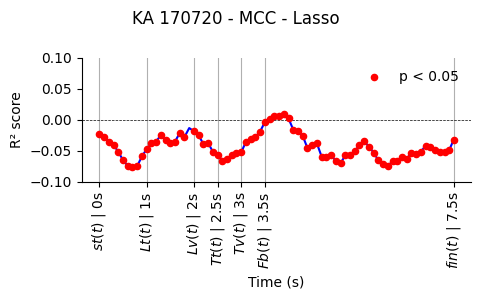

Significant time points: 75/76
Peak significant R²: 0.022
Peak time: 3.900s


In [13]:
# plot scores with significance markers

fig, ax = plt.subplots(figsize=(5, 3))

# Plot the main line
ax.plot(neural_data_temp.time, np.convolve(scores, np.ones(5)/5, mode='same'), color='blue', linewidth=1.5)

# Add significance markers
alpha = 0.05  # significance threshold
significant_mask = p_values_fdr < alpha

# Option 1: Highlight significant points with different color
ax.scatter(neural_data_temp.time[significant_mask], 
          np.convolve(scores, np.ones(5)/5, mode='same')[significant_mask], 
          color='red', s=20, zorder=5, label=f'p < {alpha}')

plot_keypoints(ax)
ax.grid(axis='x')

# Add horizontal line at zero
ax.axhline(0, color='k', linestyle='--', linewidth=0.5)

# Styling
ax.set_ylim(-.1, .1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('R² score')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend if there are significant points
if np.any(significant_mask):
    ax.legend(loc='upper right', frameon=False)

plt.suptitle(f"{monkey.upper()} {session} - {area.upper()} - Lasso", fontsize=12)
plt.tight_layout()
plt.show()

# Optional: Print summary statistics
print(f"Significant time points: {np.sum(significant_mask)}/{len(p_values_fdr)}")
if np.any(significant_mask):
    print(f"Peak significant R²: {np.max(scores[significant_mask]):.3f}")
    peak_time = neural_data_temp.time[significant_mask][np.argmax(scores[significant_mask])]
    print(f"Peak time: {peak_time:.3f}s")